In [ ]:
from sklearn.ensemble import GradientBoostingRegressorfrom sklearn.metrics import mean_absolute_error, mean_squared_errorimport timefrom ortools.linear_solver import pywraplpfrom pulp import *from scipy.optimize import linprogfrom statsmodels.tsa.arima.model import ARIMAfrom statsmodels.tsa.statespace.sarimax import SARIMAXimport numpy as npimport pandas as pdimport pyomo.environ as pyo# Define crudes: [sulfur (%), API gravity, cost ($/bbl), available volume]data = {"CrudeA": [1.2, 34, 70, 5000],"CrudeB": [0.5, 40, 80, 3000],"CrudeC": [2.0, 30, 65, 4000],}crudes = pd.DataFrame(data, index=["sulfur", "api", "cost", "avail"])# Target specstarget_sulfur_max = 1.0target_api_min = 35total_blend_volume = 6000# Decision variables: x_i = volume of Crude i to usec = crudes.loc["cost"].values  # Objective: minimize costA = []b = []# Constraint 1: total volume == total_blend_volumeA.append([1, 1, 1])b.append(total_blend_volume)# Constraint 2: sulfur weighted average <= target_sulfur_maxA.append(crudes.loc["sulfur"].values)b.append(target_sulfur_max * total_blend_volume)# Constraint 3: api weighted average >= target_api_min# Flip sign for scipy.optimize.linprog which only supports A_ubA.append([-x for x in crudes.loc["api"].values])b.append(-target_api_min * total_blend_volume)# Constraint 4: individual crudes cannot exceed availableA_bound = np.identity(3)b_bound = crudes.loc["avail"].values# Combine all constraintsA_ub = np.vstack([A, A_bound])b_ub = np.hstack([b, b_bound])# Bounds: volumes must be >= 0bounds = [(0, None)] * 3# Solveresult = linprog(c = c, A_ub = A_ub, b_ub = b_ub, bounds = bounds, method="highs")# Resultsif result.success:blend_volumes = pd.Series(result.x, index = crudes.columns)blend_cost = np.dot(c, result.x)blend_sulfur = np.dot(blend_volumes, crudes.loc["sulfur"]) / total_blend_volumeblend_api = np.dot(blend_volumes, crudes.loc["api"]) / total_blend_volumeprint("Optimal Blend (bbl):\n", blend_volumes)print(f"Total Cost: ${blend_cost:,.2f}")print(f"Blended Sulfur: {blend_sulfur:.2f}%")print(f"Blended API: {blend_api:.2f}")else:print("Optimization failed:", result.message)

Optimal Blend (bbl):
 CrudeA    2647.058824
CrudeB    3000.000000
CrudeC       0.000000
dtype: float64
Total Cost: $425,294.12
Blended Sulfur: 0.78%
Blended API: 35.00


In [ ]:
# Load and preprocess datadf = pd.read_csv("Bellevue SolarAnywhere Time Series 20230101 to 20240101 Lat_47_615 Lon_ - 122_175 SA format.csv",encoding="ISO - 8859 - 1",skiprows = 1,)df.rename(columns={"ObservationTime(LST)": "timestamp"}, inplace = True)df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")df.set_index("timestamp", inplace = True)column_map = {"Global Horizontal Irradiance (GHI) W / m2": "GHI","Direct Normal Irradiance (DNI) W / m2": "DNI","Diffuse Horizontal Irradiance (DIF) W / m2": "DHI","Wind Speed (m / s)": "Wind Speed","Wind Direction (degrees)": "Wind Direction","AmbientTemperature (deg C)": "Temperature","Relative Humidity (%)": "Humidity","Liquid Precipitation (kg / m2)": "Liquid Precip","Solid Precipitation (kg / m2)": "Solid Precip","Snow Depth (m)": "Snow Depth","Albedo": "Albedo","Particulate Matter 10 (µg / m3)": "PM10","Particulate Matter 2.5 (µg / m3)": "PM2.5",}df = df[column_map.keys()].rename(columns = column_map)df = df.apply(pd.to_numeric, errors="coerce")# Forecasting functiondef smape(y_true, y_pred):denom = np.abs(y_true) + np.abs(y_pred)return 100 * np.mean(2 * np.abs(y_pred - y_true) / np.where(denom == 0, 1, denom))def run_forecasting_pipeline(df, exog_vars, target="GHI", horizon = 30):df = df[[target] + exog_vars].resample("D").mean().interpolate("time").dropna()train, test = df.iloc[:-horizon], df.iloc[-horizon:]arima = ARIMA(train[target], order=(1, 1, 1)).fit()sarimax = SARIMAX(train[target], exog = train[exog_vars], order=(1, 1, 1)).fit()gbt = GradientBoostingRegressor().fit(train[exog_vars], train[target])preds = {"ARIMA": arima.forecast(horizon),"SARIMAX": sarimax.forecast(horizon, exog = test[exog_vars]),"GBT": gbt.predict(test[exog_vars]),}metrics = []for model, y_pred in preds.items():y_true = test[target].valuesmetrics.append({"Model": model,"MSE": mean_squared_error(y_true, y_pred),"MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,"sMAPE": smape(y_true, y_pred),})return pd.DataFrame(metrics)# Example usageresults = run_forecasting_pipeline(df, exog_vars=["Temperature", "Humidity", "Wind Speed"])print(results)

     Model          MSE  MAPE      sMAPE
0    ARIMA   911.417336   inf  76.404143
1  SARIMAX  3041.155023   inf  85.298533
2      GBT  3490.410361   inf  86.967245


/tmp/ipython-input-10-418824579.py:64: RuntimeWarning: divide by zero encountered in divide
  "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,


In [ ]:
crudes = ["A", "B", "C"]cost = {"A": 70, "B": 80, "C": 65}api = {"A": 34, "B": 40, "C": 30}sulfur = {"A": 1.2, "B": 0.5, "C": 2.0}avail = {"A": 5000, "B": 3000, "C": 4000}target_volume = 6000api_min = 35sulfur_max = 1.0model = pyo.ConcreteModel()model.crudes = pyo.Set(initialize = crudes)model.vol = pyo.Var(model.crudes, domain = pyo.NonNegativeReals)model.cost = pyo.Objective(expr = sum(model.vol[c] * cost[c] for c in model.crudes), sense = pyo.minimize)model.total_volume = pyo.Constraint(expr = sum(model.vol[c] for c in model.crudes) == target_volume)model.sulfur_limit = pyo.Constraint(expr = sum(model.vol[c] * sulfur[c] for c in model.crudes)<= sulfur_max * target_volume)model.api_limit = pyo.Constraint(expr = sum(model.vol[c] * api[c] for c in model.crudes) >= api_min * target_volume)model.avail_limits = pyo.ConstraintList()for c in model.crudes:model.avail_limits.add(model.vol[c] <= avail[c])solver = pyo.SolverFactory("glpk")result = solver.solve(model)if (result.solver.status == pyo.SolverStatus.ok) and (result.solver.termination_condition == pyo.TerminationCondition.optimal):for c in crudes:print(f"Crude {c}: {model.vol[c]():.1f} bbl")total_cost = sum(model.vol[c]() * cost[c] for c in crudes)blend_api = sum(model.vol[c]() * api[c] for c in crudes) / target_volumeblend_sulfur = sum(model.vol[c]() * sulfur[c] for c in crudes) / target_volumeprint(f"Total cost: ${total_cost:,.2f}")print(f"Blended API: {blend_api:.2f}")print(f"Blended sulfur: {blend_sulfur:.2f}%")else:print("No optimal solution found.")

Crude A: 4285.7 bbl
Crude B: 1714.3 bbl
Crude C: 0.0 bbl
Total cost: $437,142.86
Blended API: 35.71
Blended sulfur: 1.00%


In [ ]:
!pip install pyomo!apt install glpk - utils!pip install glpk

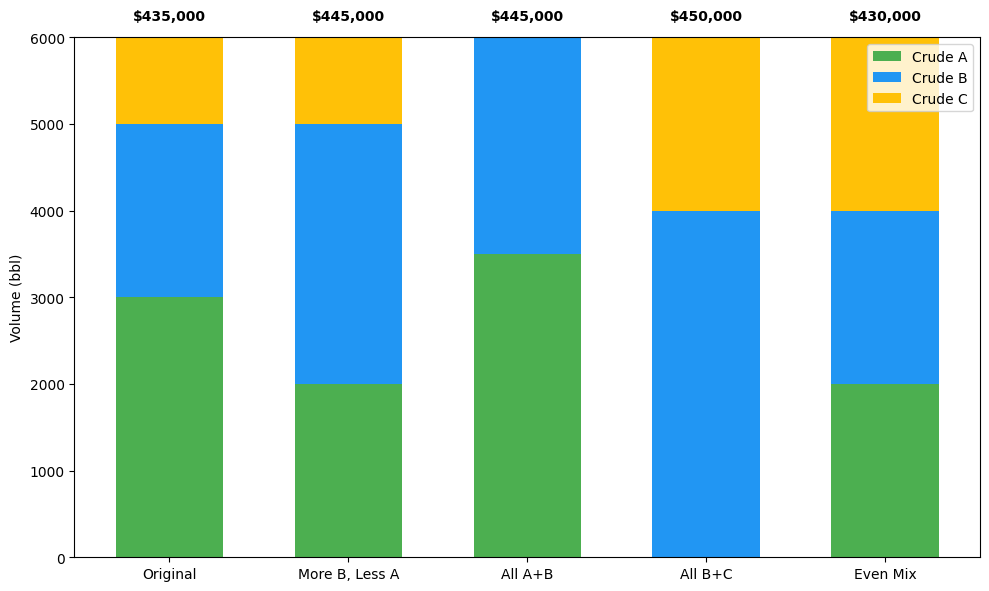

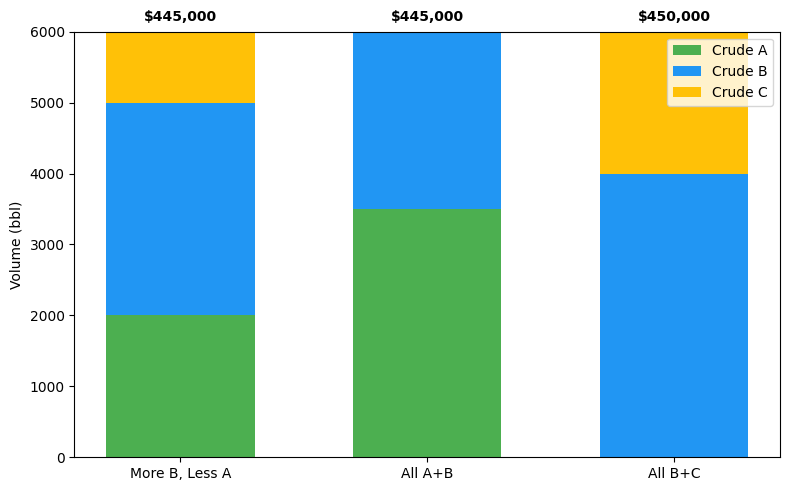

In [ ]:
model = pyo.ConcreteModel()crudes = ["A", "B", "C"]cost = {"A": 70, "B": 80, "C": 65}api = {"A": 34, "B": 40, "C": 30}sulfur = {"A": 1.2, "B": 0.5, "C": 2.0}avail = {"A": 5000, "B": 3000, "C": 4000}model.crudes = pyo.Set(initialize = crudes)model.vol = pyo.Var(model.crudes, domain = pyo.NonNegativeReals)model.cost = pyo.Objective(expr = sum(model.vol[c] * cost[c] for c in crudes), sense = pyo.minimize)model.total_volume = pyo.Constraint(expr = sum(model.vol[c] for c in crudes) == 6000)model.sulfur = pyo.Constraint(expr = sum(model.vol[c] * sulfur[c] for c in crudes) <= 6000 * 1.0)model.api = pyo.Constraint(expr = sum(model.vol[c] * api[c] for c in crudes) >= 6000 * 35)model.avail = pyo.ConstraintList()for c in crudes:model.avail.add(model.vol[c] <= avail[c])solver = pyo.SolverFactory("glpk")solver.solve(model)model = LpProblem("CrudeBlend", LpMinimize)vol = LpVariable.dicts("vol", ["A", "B", "C"], lowBound = 0)model += lpSum([vol[i] * cost[i] for i in crudes])model += lpSum([vol[i] for i in crudes]) == 6000model += lpSum([vol[i] * sulfur[i] for i in crudes]) <= 6000 * 1.0model += lpSum([vol[i] * api[i] for i in crudes]) >= 6000 * 35for i in crudes:model += vol[i] <= avail[i]model.solve()solver = pywraplp.Solver.CreateSolver("GLOP")vol = {i: solver.NumVar(0, avail[i], i) for i in crudes}solver.Add(solver.Sum([vol[i] for i in crudes]) == 6000)solver.Add(solver.Sum([vol[i] * sulfur[i] for i in crudes]) <= 6000 * 1.0)solver.Add(solver.Sum([vol[i] * api[i] for i in crudes]) >= 6000 * 35)solver.Minimize(solver.Sum([vol[i] * cost[i] for i in crudes]))status = solver.Solve()

In [ ]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
ydf 0.12.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 6.31.1 which is incom

In [ ]:
# Re - import required libraries after kernel reset# Shared datacrudes = ["A", "B", "C"]cost = {"A": 70, "B": 80, "C": 65}api = {"A": 34, "B": 40, "C": 30}sulfur = {"A": 1.2, "B": 0.5, "C": 2.0}avail = {"A": 5000, "B": 3000, "C": 4000}target_vol = 6000sulfur_max = 1.0api_min = 35results = {}# Pyomostart = time.time()model_pyo = pyo.ConcreteModel()model_pyo.crudes = pyo.Set(initialize = crudes)model_pyo.vol = pyo.Var(model_pyo.crudes, domain = pyo.NonNegativeReals)model_pyo.cost = pyo.Objective(expr = sum(model_pyo.vol[c] * cost[c] for c in crudes), sense = pyo.minimize)model_pyo.total_volume = pyo.Constraint(expr = sum(model_pyo.vol[c] for c in crudes) == target_vol)model_pyo.sulfur = pyo.Constraint(expr = sum(model_pyo.vol[c] * sulfur[c] for c in crudes) <= target_vol * sulfur_max)model_pyo.api = pyo.Constraint(expr = sum(model_pyo.vol[c] * api[c] for c in crudes) >= target_vol * api_min)model_pyo.avail = pyo.ConstraintList()for c in crudes:model_pyo.avail.add(model_pyo.vol[c] <= avail[c])solver = pyo.SolverFactory("glpk")solver.solve(model_pyo)end = time.time()results["Pyomo"] = {"runtime_sec": end - start,"volumes": {c: model_pyo.vol[c]().round(2) for c in crudes},"cost": sum(model_pyo.vol[c]() * cost[c] for c in crudes),}# PuLPstart = time.time()model_pulp = LpProblem("CrudeBlend", LpMinimize)vol_pulp = LpVariable.dicts("vol", crudes, lowBound = 0)model_pulp += lpSum([vol_pulp[i] * cost[i] for i in crudes])model_pulp += lpSum([vol_pulp[i] for i in crudes]) == target_volmodel_pulp += (lpSum([vol_pulp[i] * sulfur[i] for i in crudes]) <= target_vol * sulfur_max)model_pulp += lpSum([vol_pulp[i] * api[i] for i in crudes]) >= target_vol * api_minfor i in crudes:model_pulp += vol_pulp[i] <= avail[i]model_pulp.solve()end = time.time()results["PuLP"] = {"runtime_sec": end - start,"volumes": {c: vol_pulp[c].varValue for c in crudes},"cost": value(model_pulp.objective),}# OR - Toolsstart = time.time()solver = pywraplp.Solver.CreateSolver("GLOP")vol_ort = {i: solver.NumVar(0, avail[i], i) for i in crudes}solver.Add(solver.Sum([vol_ort[i] for i in crudes]) == target_vol)solver.Add(solver.Sum([vol_ort[i] * sulfur[i] for i in crudes]) <= target_vol * sulfur_max)solver.Add(solver.Sum([vol_ort[i] * api[i] for i in crudes]) >= target_vol * api_min)solver.Minimize(solver.Sum([vol_ort[i] * cost[i] for i in crudes]))status = solver.Solve()end = time.time()results["OR - Tools"] = {"runtime_sec": end - start,"volumes": {c: vol_ort[c].solution_value() for c in crudes},"cost": sum(vol_ort[c].solution_value() * cost[c] for c in crudes),}df = pd.DataFrame(results).Tdf["cost"] = df["cost"].round(2)df["runtime_sec"] = df["runtime_sec"].round(6)

AttributeError: 'float' object has no attribute 'round'

In [ ]:
# Fixing the .round() call on float object (should use round() function, not method)# Shared datacrudes = ["A", "B", "C"]cost = {"A": 70, "B": 80, "C": 65}api = {"A": 34, "B": 40, "C": 30}sulfur = {"A": 1.2, "B": 0.5, "C": 2.0}avail = {"A": 5000, "B": 3000, "C": 4000}target_vol = 6000sulfur_max = 1.0api_min = 35results = {}# Pyomostart = time.time()model_pyo = pyo.ConcreteModel()model_pyo.crudes = pyo.Set(initialize = crudes)model_pyo.vol = pyo.Var(model_pyo.crudes, domain = pyo.NonNegativeReals)model_pyo.cost = pyo.Objective(expr = sum(model_pyo.vol[c] * cost[c] for c in crudes), sense = pyo.minimize)model_pyo.total_volume = pyo.Constraint(expr = sum(model_pyo.vol[c] for c in crudes) == target_vol)model_pyo.sulfur = pyo.Constraint(expr = sum(model_pyo.vol[c] * sulfur[c] for c in crudes) <= target_vol * sulfur_max)model_pyo.api = pyo.Constraint(expr = sum(model_pyo.vol[c] * api[c] for c in crudes) >= target_vol * api_min)model_pyo.avail = pyo.ConstraintList()for c in crudes:model_pyo.avail.add(model_pyo.vol[c] <= avail[c])solver = pyo.SolverFactory("glpk")solver.solve(model_pyo)end = time.time()results["Pyomo"] = {"runtime_sec": round(end - start, 6),"volumes": {c: round(pyo.value(model_pyo.vol[c]), 2) for c in crudes},"cost": round(sum(pyo.value(model_pyo.vol[c]) * cost[c] for c in crudes), 2),}# PuLPstart = time.time()model_pulp = LpProblem("CrudeBlend", LpMinimize)vol_pulp = LpVariable.dicts("vol", crudes, lowBound = 0)model_pulp += lpSum([vol_pulp[i] * cost[i] for i in crudes])model_pulp += lpSum([vol_pulp[i] for i in crudes]) == target_volmodel_pulp += (lpSum([vol_pulp[i] * sulfur[i] for i in crudes]) <= target_vol * sulfur_max)model_pulp += lpSum([vol_pulp[i] * api[i] for i in crudes]) >= target_vol * api_minfor i in crudes:model_pulp += vol_pulp[i] <= avail[i]model_pulp.solve()end = time.time()results["PuLP"] = {"runtime_sec": round(end - start, 6),"volumes": {c: round(vol_pulp[c].varValue, 2) for c in crudes},"cost": round(value(model_pulp.objective), 2),}# OR - Toolsstart = time.time()solver = pywraplp.Solver.CreateSolver("GLOP")vol_ort = {i: solver.NumVar(0, avail[i], i) for i in crudes}solver.Add(solver.Sum([vol_ort[i] for i in crudes]) == target_vol)solver.Add(solver.Sum([vol_ort[i] * sulfur[i] for i in crudes]) <= target_vol * sulfur_max)solver.Add(solver.Sum([vol_ort[i] * api[i] for i in crudes]) >= target_vol * api_min)solver.Minimize(solver.Sum([vol_ort[i] * cost[i] for i in crudes]))status = solver.Solve()end = time.time()results["OR - Tools"] = {"runtime_sec": round(end - start, 6),"volumes": {c: round(vol_ort[c].solution_value(), 2) for c in crudes},"cost": round(sum(vol_ort[c].solution_value() * cost[c] for c in crudes), 2),}df = pd.DataFrame(results).T

In [ ]:
df.head()

,runtime_sec,volumes,cost
Pyomo,0.025715,"{'A': 4285.71, 'B': 1714.29, 'C': 0.0}",437142.86
PuLP,0.019173,"{'A': 4285.71, 'B': 1714.29, 'C': 0.0}",437142.86
OR-Tools,0.005076,"{'A': 4285.71, 'B': 1714.29, 'C': 0.0}",437142.86


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('runtime_sec').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)